## CSV Data

In [93]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

In [94]:
from sklearn.datasets import load_breast_cancer

In [95]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target
df_clean = df.dropna()

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.drop(columns = ['target']))
X_scaled
y = df_clean['target']

In [97]:
mds = MDS(n_components = 2, random_state = 1, n_jobs = -1)
X_mds = mds.fit_transform(X_scaled)

c:\Users\shaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


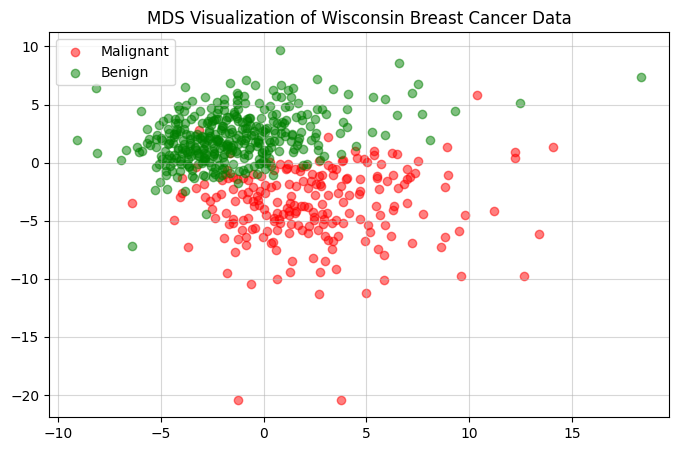

In [98]:
plt.figure(figsize = (8, 5))
for label, color in zip ([0,1], ['red', 'green']):
    plt.scatter(X_mds[y == label, 0], X_mds[y==label, 1], label = 'Malignant' if label ==0 else "Benign", color = color, alpha = 0.5)

plt.title("MDS Visualization of Wisconsin Breast Cancer Data")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

---

In [99]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

In [100]:
path = "datasets/SpotifyAudioFeatures.csv"
data2 = pd.read_csv(path)
data2.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [101]:
FEATURE_COLUMNS = ['acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity']
X = data2[FEATURE_COLUMNS]
y = data2['energy']

X.head()

,acousticness,instrumentalness,liveness,speechiness,tempo,popularity
0,0.005820,0.000,0.0812,0.4090,203.927,15
1,0.024400,0.000,0.2860,0.4570,159.009,0
2,0.025000,0.000,0.0824,0.0454,114.966,56
3,0.029400,0.912,0.0994,0.0701,123.003,0
4,0.000035,0.878,0.0332,0.0661,120.047,0


In [102]:
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

print(X_scaled.shape, y.shape)

(130663, 6) (130663,)


In [103]:
X_inp = X[:1000]
y_inp = y[:1000]

print(X_inp.shape, y_inp.shape)

(1000, 6) (1000,)


In [104]:
mds2 = MDS(n_components = 2, random_state = 1, n_jobs = -1 )
X_mds2 = mds2.fit_transform(X_inp)

c:\Users\shaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


ValueError: 'c' argument has 1000 elements, which is inconsistent with 'x' and 'y' with size 569.

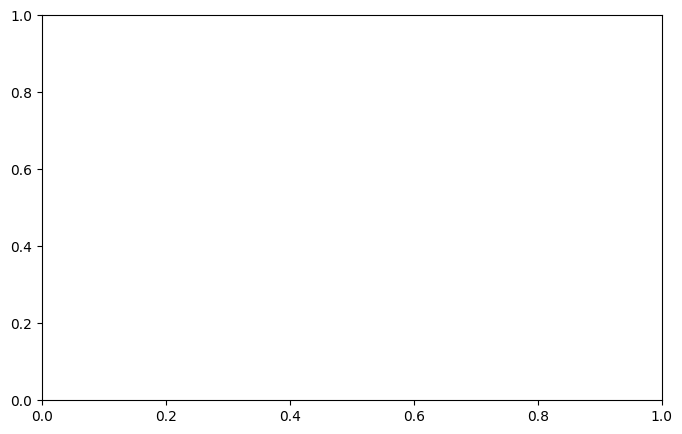

In [105]:
plt.figure(figsize= (8,5))
plt.scatter(X_mds[:,0], X_mds[:,1], c = y_inp, cmap = 'Viridis', alpha = 0.5)
plt.title("Spotify")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

## Audio Datafile

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

In [2]:
df = pd.read_csv("datasets/SpotifyAudioDataset.csv")
print(f"Raw shape: {df.shape}")
print(df.head())


Raw shape: (114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57   

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
df.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
FEATURES = [
'danceability', 'energy', 'loudness', 'speechiness',
'acousticness', 'instrumentalness', 'liveness',
'valence', 'tempo', 'duration_ms', 'popularity'
]


In [6]:
df = df.dropna(subset=FEATURES + ['track_genre'])
df = df.drop_duplicates(subset=['track_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89741 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        89741 non-null  int64  
 1   track_id          89741 non-null  object 
 2   artists           89740 non-null  object 
 3   album_name        89740 non-null  object 
 4   track_name        89740 non-null  object 
 5   popularity        89741 non-null  int64  
 6   duration_ms       89741 non-null  int64  
 7   explicit          89741 non-null  bool   
 8   danceability      89741 non-null  float64
 9   energy            89741 non-null  float64
 10  key               89741 non-null  int64  
 11  loudness          89741 non-null  float64
 12  mode              89741 non-null  int64  
 13  speechiness       89741 non-null  float64
 14  acousticness      89741 non-null  float64
 15  instrumentalness  89741 non-null  float64
 16  liveness          89741 non-null  float64
 1

In [7]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [8]:
TOP_N = 10
top_genres = df['track_genre'].value_counts().head(TOP_N).index.tolist()
df = df[df['track_genre'].isin(top_genres)].copy()
print(f"Filtered: {len(df)} tracks, {TOP_N} genres")
# ── 4. Stratified sub-sample (speed) ──────────────────────────────────────
N_TOTAL = 1500 # increase for denser plots
per_genre = N_TOTAL // TOP_N
df_s = (
df.groupby('track_genre', group_keys=False)
.apply(lambda g: g.sample(min(len(g), per_genre), random_state=1))
.reset_index(drop=True)
)
print(f"Sampled: {len(df_s)} tracks (~{per_genre} per genre)")
X_raw = df_s[FEATURES].values
genres = df_s['track_genre'].values

Filtered: 9987 tracks, 10 genres
Sampled: 1500 tracks (~150 per genre)


C:\Users\shaji\AppData\Local\Temp\ipykernel_15864\2132201896.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_genre), random_state=1))


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [10]:
mds = MDS(
n_components=2,
dissimilarity='euclidean',
metric=True, # classical metric MDS
n_init=4,
max_iter=500,
random_state=42,
n_jobs=-1,
)
X_mds = mds.fit_transform(X)
print(f"MDS stress: {mds.stress_:.4f}")
print('MDS output shape:', X_mds.shape)

MDS stress: 1747511.7613
MDS output shape: (1500, 2)


In [18]:
p = 30 #perplexity
tsne = TSNE( n_components=2,
metric='euclidean',
perplexity=p,
learning_rate='auto',
max_iter=1000,
random_state=1,
n_jobs=-1,
)
X_tsne = tsne.fit_transform(X)


In [19]:
PALETTE = [
'#1DB954', '#1E90FF', '#FF6347', '#FFD700','#DA70D6', 
'#00CED1', '#FF8C00', '#ADFF2F', '#000000','#7F00FF'
]
genre_list = sorted(top_genres)
color_map = {g: PALETTE[i] for i, g in enumerate(genre_list)}
point_colors = [color_map[g] for g in genres]

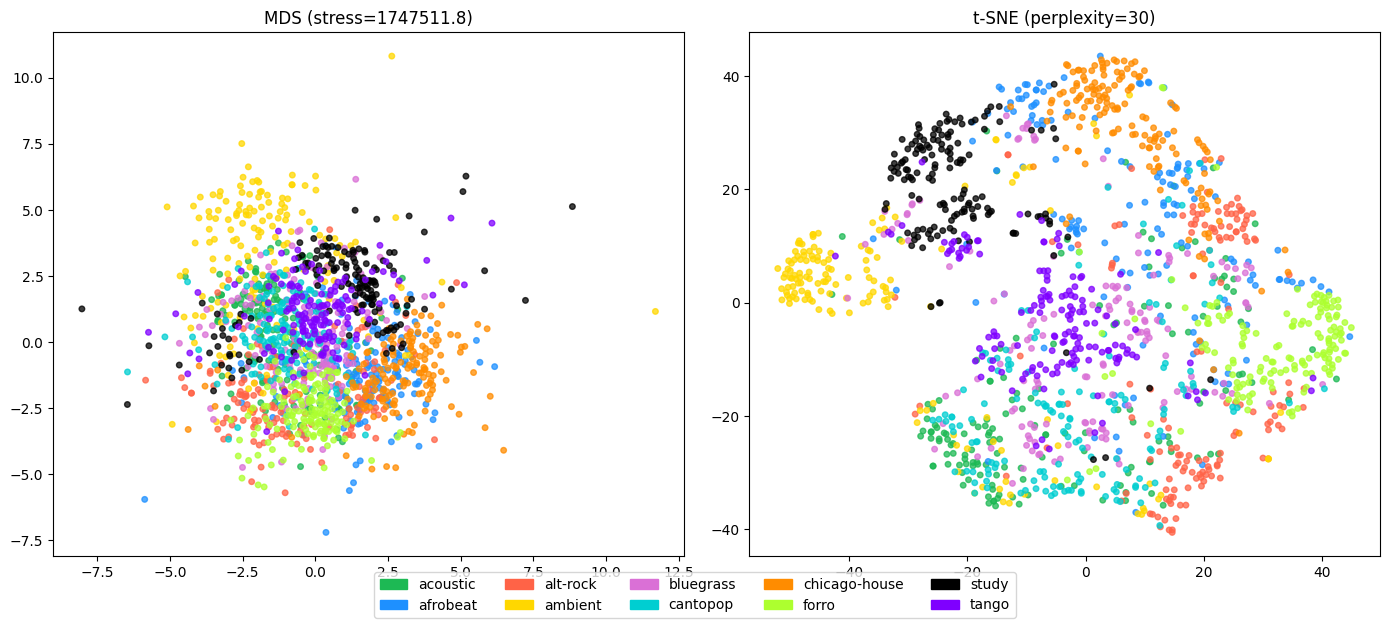

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in zip(axes,
    [X_mds, X_tsne],
    [f"MDS (stress={mds.stress_:.1f})", f"t-SNE (perplexity={p})"]):
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=16, alpha=0.75)
    ax.set_title(title)
handles = [mpatches.Patch(color=color_map[g], label=g) for g in genre_list]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.05)
)
plt.tight_layout()
plt.show()
